In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import matplotlib.pyplot as plt
import numpy as np 
set_seed(0) 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/mixer_tpp_20260202-204248") 
# checkpoints/reg_mixer_attnpl_t_20260131-114145
checkpoint_path = checkpoint_dir / "last_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

MixerTPP context size: 64
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'mixer_tpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 0.01, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'hf_cosine', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'use_amp': False, 'dropout': 0.3, 'd_model': 64, 'mixer_model_config': {'input_dim': 1, 'dropout_prob': 0.1, 'd_model': 64, 'n_layer': 1, 'd_intermediate': 128, 'attn_layer_idx': [], 'input_proj_type': 'mlp', 'input_proj_hidden': 128, 'input_proj_activation': 'silu', 'input_proj_dropout': 0.1, 'input_init': 'kaiming_uniform', 'input_init_scale': 1.5, 'ssm_cfg': {'layer': 'Mamba2Rotary', 'use_conv': False, 'rotary_emb_scale_base': 2048}, 'attn_cfg': {'layer': 'MHATime', 'num_heads': 4, 'r

OptimizedModule(
  (_orig_mod): MixerTPP(
    (base_model): MixerModelWrapper(
      (encoder): MixerModel(
        (input_proj): Sequential(
          (0): Linear(in_features=1, out_features=128, bias=True)
          (1): SiLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=128, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0): Block(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mixer): Mamba2Rotary(
              (in_proj): Linear(in_features=64, out_features=514, bias=False)
              (act): SiLU()
              (norm): RMSNorm()
              (out_proj): Linear(in_features=128, out_features=64, bias=False)
              (rotary_emb): RotaryEmbeddingTime()
            )
            (dropout): Dropout(p=0.1, inplace=False)
            (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mlp): GatedMLP(
  

In [3]:
model.base_model.encoder.layers[0]

Block(
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (mixer): Mamba2Rotary(
    (in_proj): Linear(in_features=64, out_features=514, bias=False)
    (act): SiLU()
    (norm): RMSNorm()
    (out_proj): Linear(in_features=128, out_features=64, bias=False)
    (rotary_emb): RotaryEmbeddingTime()
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (mlp): GatedMLP(
    (fc1): Linear(in_features=64, out_features=256, bias=False)
    (fc2): Linear(in_features=128, out_features=64, bias=False)
  )
)

In [3]:
from src.data.preparation import prepare_data_tpp
base_dir = f"../data/{args.dataset}"
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data_tpp(base_dir=base_dir, args=args,)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/AZDX/raw.
Using Bayesian GR b-value updater with delta=0.98, a0=50.0, init b=1.0000, mag_completeness=4.5
TPP pretrain mode: using all splits as training, disabling val/test loaders.


  0%|          | 0/45 [00:00<?, ?it/s]

[split_sequence] t_start: 316.3100, t_end: 883.8222
[split_sequence] Window duration: 567.5122
[split_sequence] Short sequence NLL start set to 441.9111
[split_sequence] t_start: 629.4130, t_end: 1325.7333
[split_sequence] Window duration: 696.3203
[split_sequence] Short sequence NLL start set to 883.8222
[split_sequence] t_start: 1038.3400, t_end: 1767.6444
[split_sequence] Window duration: 729.3045
[split_sequence] Short sequence NLL start set to 1325.7333
[split_sequence] t_start: 1399.1500, t_end: 2209.5556
[split_sequence] Window duration: 810.4055
[split_sequence] Short sequence NLL start set to 1767.6444
[split_sequence] t_start: 1868.6000, t_end: 2651.4667
[split_sequence] Window duration: 782.8667
[split_sequence] Short sequence NLL start set to 2209.5556
[split_sequence] t_start: 2417.2000, t_end: 3093.3778
[split_sequence] Window duration: 676.1778
[split_sequence] Short sequence NLL start set to 2651.4667
[split_sequence] t_start: 2846.3999, t_end: 3535.2889
[split_sequence

/root/autodl-tmp/chuandian_eq/src/data/sequence.py:246: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


In [4]:
for batch in train_loader:
    batch = batch.to(device)
    print(batch.arrival_times)
    break

tensor([[316.3100, 316.3430, 316.5250,  ..., 883.0280, 883.6810, 883.8221]],
       device='cuda:0')


Hooking module: <class 'src.models.mamba.mixer_seq.MixerModel'>


/root/miniconda3/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


Valid tokens: 6001/6001 (100.00%)
mean (all): 0.05038102716207504
std  (all): 1.0194798707962036
min  (all): -4.606949329376221
max  (all): 5.740220546722412
mean (masked): 0.05038102716207504
std  (masked): 1.0194798707962036
min  (masked): -4.606949329376221
max  (masked): 5.740220546722412


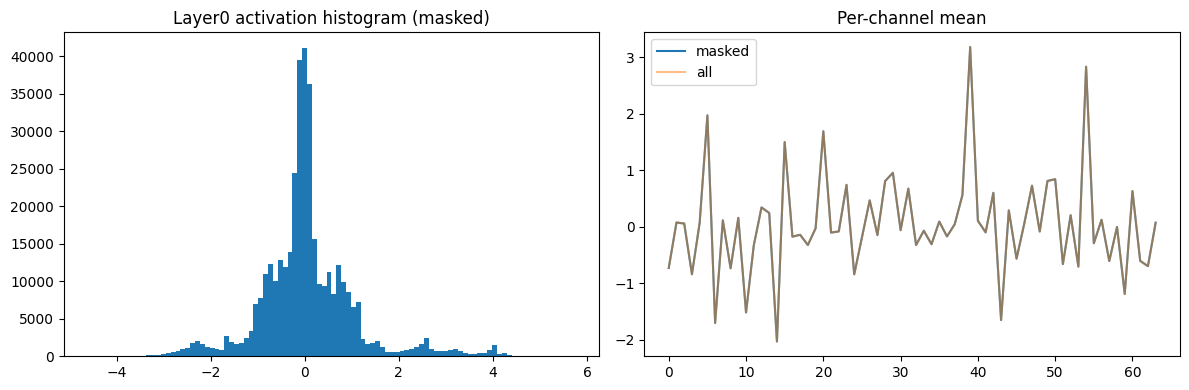

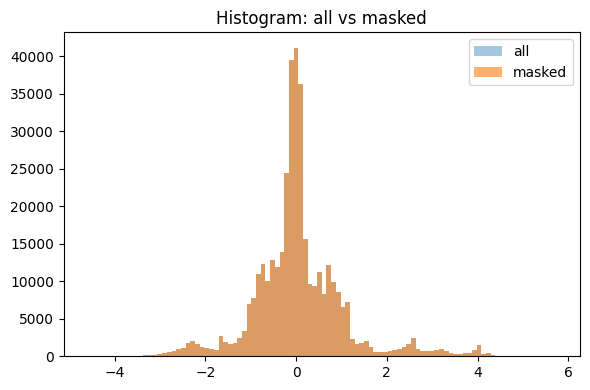

In [5]:
import matplotlib.pyplot as plt
# Capture activations after encoder layer[0]
layer0_out = []

def _hook(module, inp, out):
    # out may be tuple: (hidden_states, residual)
    if isinstance(out, tuple):
        out = out[0]
    layer0_out.append(out.detach().cpu())

print("Hooking module:", type(model.base_model.encoder))
# Prefer hook on first encoder block which is guaranteed to run
hook_handle = model.base_model.encoder.register_forward_hook(_hook)

with torch.no_grad():
    _ = model(batch)

hook_handle.remove()

# ===== visualize =====
if len(layer0_out) > 0:
    h = layer0_out[0]   # (B, L, D)

    # Build valid mask from input x: non-padded tokens
    valid_mask = batch.non_pad_mask  # (B, L)
    if isinstance(valid_mask, torch.Tensor):
        valid_mask = valid_mask.bool().cpu()

    n_valid = int(valid_mask.sum().item())
    n_total = int(valid_mask.numel())
    print(f"Valid tokens: {n_valid}/{n_total} ({100.0*n_valid/n_total:.2f}%)")

    # Global stats (unmasked)
    print("mean (all):", h.mean().item())
    print("std  (all):", h.std().item())
    print("min  (all):", h.min().item())
    print("max  (all):", h.max().item())

    # Masked activations (only valid positions)
    h_valid = h[valid_mask]  # (N_valid, D)

    # Global stats (masked)
    print("mean (masked):", h_valid.mean().item())
    print("std  (masked):", h_valid.std().item())
    print("min  (masked):", h_valid.min().item())
    print("max  (masked):", h_valid.max().item())

    # Per-channel mean
    channel_means_all = h.mean(dim=(0, 1)).numpy()
    channel_means_masked = h_valid.mean(dim=0).numpy()

    # Flatten histograms
    h_flat_all = h.reshape(-1).numpy()
    h_flat_masked = h_valid.reshape(-1).numpy()

    # Histograms: masked vs all
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.hist(h_flat_masked, bins=100)
    plt.title("Layer0 activation histogram (masked)")
    plt.subplot(1,2,2)
    plt.plot(channel_means_masked, label="masked")
    plt.plot(channel_means_all, alpha=0.5, label="all")
    plt.title("Per-channel mean")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optional: overlay hist comparison
    plt.figure(figsize=(6,4))
    plt.hist(h_flat_all, bins=100, alpha=0.4, label="all")
    plt.hist(h_flat_masked, bins=100, alpha=0.6, label="masked")
    plt.legend()
    plt.title("Histogram: all vs masked")
    plt.tight_layout()
    plt.show()
else:
    print("No activations captured.")